Inputs shape: (37, 4)
Outputs shape: (37,)
First 20 rows of raw data:
    hype-para--1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source
27      0.577766     0.428772     0.425826     0.249007        -4.025542    file
36      0.572134     0.415866     0.465114     0.491781        -4.550363  week-7
30      0.469388     0.448980     0.469388     0.204082        -4.620232  week-1
31      0.515152     0.484848     0.363636     0.181819        -4.939960  week-2
32      0.515152     0.484848     0.363636     0.181819        -5.313374  week-3
24      0.326076     0.472367     0.453192     0.105887        -6.702089    file
34      0.343612     0.592249     0.651353     0.444513        -7.221570  week-5
35      0.445393     0.174795     0.339088     0.116347        -7.600577  week-6
23      0.282138     0.505987     0.530531     0.096302        -7.966775    file
4       0.124871     0.129770     0.384400     0.287076       -10.069633    file
21      0.170347     0.756959     0.276

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/data/BaseDataHandler.py:134: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_copy = pd.concat([df, new_df], ignore_index=True)


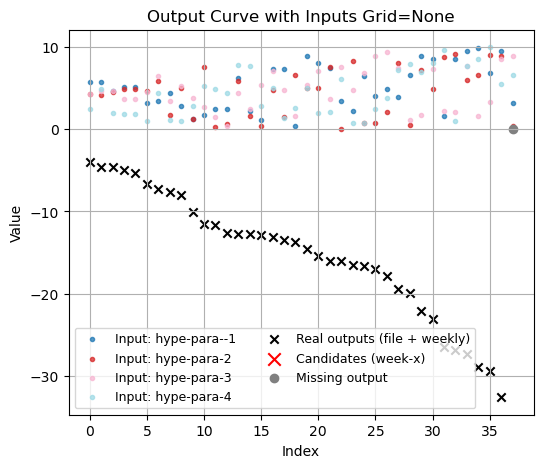

Saved LLM candidates to: results/run_2025-12-19 03-24-07/df_llm_candidates.csv

Pipeline finished.
Pipeline finished. Results keys: ['llm']


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))